In [1]:
import time
import numpy as np
import torch
import tensorflow as tf
from PIL import Image
import requests
from io import BytesIO

C:\Users\SUSHIL KUMAR SAHOO\AppData\Roaming\Python\Python310\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
def arr_multiplication(type_arr, arr1, arr2):
    t1 = time.perf_counter()

    if type_arr == 'normal_list':
        res = 0
        for i in(range(len(arr1))):
            res += arr1[i]*arr2[i]
    
    elif type_arr == 'np_arr':
        res = np.dot(arr1, arr2)
    elif type_arr == 'torch_arr':
        res = torch.matmul(arr1, arr2)
        if arr1.is_cuda:
            torch.cuda.synchronize()  # Wait for GPU computation to complete
    else:
        # tf.tensordot handles 1D vector dot product
        res = tf.tensordot(arr1, arr2, axes=1)
        
    t2 = time.perf_counter()
    time_diff = t2 - t1
    print(f"{type_arr} result: {res} | time_taken: {time_diff:.6f} s")


In [3]:
# 1. Normal Python list 
list1 = [1]*1000000
list2 = [2]*len(list1)
arr_multiplication('normal_list',list1,list2)

# 2. NumPy (float64)
np_arr = np.arange(1000000, dtype=np.float64)
np_arr2 = np_arr * 23 + 1 + 3
arr_multiplication('np_arr', np_arr, np_arr2)

# 3. PyTorch (float32 / float64)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_arr = torch.ones(1000000, dtype=torch.float32, device=device)
torch_arr2 = torch_arr + 230 + 21 - 2
arr_multiplication('torch_arr', torch_arr, torch_arr2)

# 4. TensorFlow (float32 / float64)
tf_arr = tf.range(1000000, dtype=tf.float32)
tf_arr2 = tf_arr + 23 + 12 + 2
arr_multiplication('tf_arr', tf_arr, tf_arr2)

normal_list result: 2000000 | time_taken: 0.304539 s
np_arr result: 7.66665716666836e+18 | time_taken: 0.002016 s
torch_arr result: 250000000.0 | time_taken: 0.118470 s
tf_arr result: 3.333524779297669e+17 | time_taken: 0.051340 s


In [4]:
res = 0
t1 = time.perf_counter()
for i in range(len(np_arr)):
    res += np_arr[i]*np_arr2[i]
t2 = time.perf_counter()
time_diff = t2 - t1
print(f"result: {res} | time_taken: {time_diff:.6f} s")

result: 7.666657166666563e+18 | time_taken: 0.418926 s


#### Cosine Similarity : 

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sentences = [
    "The cat sat on the mat.",
    "A cat sat on a mat.",
    "Space rockets explore distant stars."
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(sentences)

print(f"Vocabulary : {vectorizer.get_feature_names_out()}")

similarity_matrix  = cosine_similarity(X)
print(similarity_matrix.round(2))

print(f"\nSimilarity between Sentence A and B: {similarity_matrix[0][1]:.2f}")
print(f"Similarity between Sentence A and C: {similarity_matrix[0][2]:.2f}")

Vocabulary : ['cat' 'distant' 'explore' 'mat' 'on' 'rockets' 'sat' 'space' 'stars'
 'the']
[[1.   0.71 0.  ]
 [0.71 1.   0.  ]
 [0.   0.   1.  ]]

Similarity between Sentence A and B: 0.71
Similarity between Sentence A and C: 0.00


### Matrix Transformation Using Numpy :

A Shape: (553, 555)
A Data type: uint8
A Dimension: 2


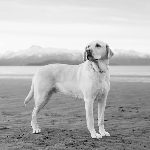

In [6]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS_sH47dHBeNkmS6X97RaxgKrE_NzX4RHAZRkwvYggbcqyIi6WAqnLWngqK&s=10"
# 1. Download the image data from the URL
response = requests.get(url)
# 2. Wrap the binary data in BytesIO and open it with Pillow
img = Image.open(BytesIO(response.content)).convert("L")
# 3. Convert to Numpy array

A = np.array(img)
print("A Shape:", A.shape)
print("A Data type:", A.dtype)
print("A Dimension:", A.ndim)

def show_matrix(matrix_x):
    img = Image.fromarray(matrix_x, mode="L")
    img = img.resize((150,150), Image.Resampling.NEAREST)
    display(img)

show_matrix(A)

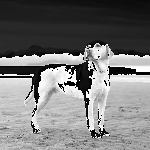

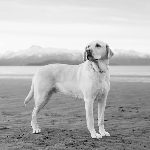

In [7]:
# scalar addition/ difference
B = np.clip(A + 50, 0, 255).astype(np.uint8)    # (mat_op,min,max)

show_matrix(B)
show_matrix(B-50)


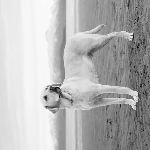

In [8]:
# transpose of matrix 
show_matrix(A.T)
# show_matrix(np.transpose(A))


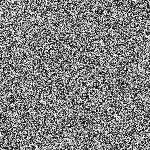

In [9]:
# matrix multipliacation 
show_matrix(A.T @ A)

In [10]:
# Determinant of a matrix :
B = A[0:4,0:4]  # A square matrix of (4,4)
print(B) 
print("----------It's rows or columns are linearly dependent")
print('So Detrminant of matrix B :',np.linalg.det(B))

[[227 227 227 227]
 [227 227 227 227]
 [228 228 228 228]
 [230 230 230 230]]
----------It's rows or columns are linearly dependent
So Detrminant of matrix B : 0.0


In [11]:
C = [[1,0,0],
     [9,1,3],
     [2,0,1]]  
print("It's rows or columns are linearly independent")
print('So Detrminant of matrix C :',np.linalg.det(C))

It's rows or columns are linearly independent
So Detrminant of matrix C : 1.0


In [12]:
np.linalg.inv(C)

array([[ 1.,  0.,  0.],
       [-3.,  1., -3.],
       [-2., -0.,  1.]])

In [13]:
# Trace of a matrix
np.linalg.trace(B)

np.uint64(912)

In [14]:
# rank of a matrix :   shows the exact number of linearly independent rows or columns in a matrix
print(np.linalg.matrix_rank(B))
print(np.linalg.matrix_rank(C))
print(np.linalg.matrix_rank(A))

1
3
525


In [15]:
# finding the eigen value of matrix : It reduces the dimensions of matrix for faster computation during training
print(np.linalg.eig(C))

EigResult(eigenvalues=array([1., 1., 1.]), eigenvectors=array([[ 0.00000000e+00,  0.00000000e+00,  8.21730110e-33],
       [ 1.00000000e+00, -1.00000000e+00,  1.00000000e+00],
       [ 0.00000000e+00,  7.40148683e-17, -7.40148683e-17]]))


## [Chapter 4 : Open Matrix Multiplication PDF](./learning_materials/04_Matrix_Vector_Multiplication.pdf)